Generating arrays for h5 file

In [65]:
import glob
import h5py
import importlib
import IPython.display as ipd
import soxr
import numpy as np
import os
import pandas as pd
import pickle
import soundfile as sf
import src.audio_transforms as at
import src.custom_modules as cm
from src.binaural_attn_lightning import BinauralAttentionModule
import sys
import torch
import tqdm
import yaml

from pathlib import Path
from pytorch_lightning import Trainer
from scipy import signal
from scipy.io.wavfile import read, write

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
# path to 376 wiki words
swc_path = '/om2/user/msaddler/spatial_audio_pipeline/assets/human_experiment_v00/foreground_swc/'

# path o common voice words not included in training
df = pd.read_pickle('/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/commonvoice_9_en/manifest_all_word_alignments.pdpkl')

In [3]:
manifest = pd.read_pickle(swc_path + 'manifest.pdpkl')

In [4]:
manifest

,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,raw_clip_dur_in_s,raw_clip_end_in_s,raw_clip_start_in_s,raw_src_fn,raw_total_file_duration_in_s,split,split_int,sr,src_fn,total_file_duration_in_s,word
0,a-c-norman,3.0,3.0,0.0,swc,0.32,2094.94,2094.62,/scratch2/weka/mcdermott/msaddler/swc/english/...,2175.444172,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,above
1,jebjoya,3.0,3.0,0.0,swc,0.49,1715.87,1715.38,/scratch2/weka/mcdermott/msaddler/swc/english/...,2793.356190,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,according
2,caninedoubletake,3.0,3.0,0.0,swc,0.36,169.03,168.67,/scratch2/weka/mcdermott/msaddler/swc/english/...,987.438730,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,across
3,karltalk,3.0,3.0,0.0,swc,0.60,2429.51,2428.91,/scratch2/weka/mcdermott/msaddler/swc/english/...,4802.892336,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,action
4,s-whistler,3.0,3.0,0.0,swc,0.80,1149.87,1149.07,/scratch2/weka/mcdermott/msaddler/swc/english/...,4463.715556,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,activities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,incledon,3.0,3.0,0.0,swc,0.69,231.72,231.03,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.573152,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,world
372,ama1016,3.0,3.0,0.0,swc,0.42,193.47,193.05,/scratch2/weka/mcdermott/msaddler/swc/english/...,273.502041,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,writing
373,zanimum,3.0,3.0,0.0,swc,0.27,13.92,13.65,/scratch2/weka/mcdermott/msaddler/swc/english/...,452.154921,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,written
374,tonyle,3.0,3.0,0.0,swc,0.31,1208.98,1208.67,/scratch2/weka/mcdermott/msaddler/swc/english/...,2359.540680,eval,2,44100,/om2/user/msaddler/spatial_audio_pipeline/asse...,3.0,wrote


In [5]:
fn_pkl_src = '/scratch2/weka/mcdermott/raygon/projects/public/jsinDataset/assets/data/interim/swc/mungedFinalDataframeWords_swc_readerNormalized_sexNormalized_accent.pdpkl'
fn_pkl_dst = '/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl'

In [6]:
word_dict = pickle.load(open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", 'rb'))

In [7]:
words = list(word_dict.keys())

In [8]:
words = [word.replace("'", "") for word in words]

In [9]:
manifest_all_words = pd.read_pickle(fn_pkl_dst)

In [10]:
# filter out words not in 'words' list
manifest_all_words = manifest_all_words[manifest_all_words['word'].isin(words)]

In [11]:
len(manifest_all_words['word'].unique())

791

In [12]:
word_counts = manifest_all_words['word'].value_counts()

In [13]:
down_df = manifest_all_words.groupby(['word', 'gender']).sample(1, replace=False)

In [14]:
final_df = down_df.groupby('word').filter(lambda x: len(x) == 2)

In [15]:
final_df = final_df.reset_index().rename(columns={'index':'src_ix'})

In [16]:
final_df

,src_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,sr,src_fn,total_file_duration_in_s,word
0,601525,laura-s,0.33,1196.46,1196.13,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1796.176689,about
1,367202,viktor-o-ledenyov,0.48,823.79,823.31,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1801.002086,about
2,641361,dolliellama,0.30,2923.26,2922.96,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,4871.649524,above
3,435010,matthewdgonzalez,0.37,1524.24,1523.87,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,2659.861769,above
4,247298,ama1016,0.56,706.04,705.48,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1181.505306,access
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,653426,donbert,0.35,1554.46,1554.11,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1597.876825,yellow
1574,136224,popularoutcast,0.60,780.23,779.63,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1160.012336,young
1575,552100,joaopais,0.30,470.78,470.48,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,655.248254,young
1576,701035,flyingtoaster,0.28,247.74,247.46,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1973.849977,younger


In [17]:
all_words_not_filtered = pd.read_pickle(fn_pkl_dst)
oov_words = all_words_not_filtered[~all_words_not_filtered['word'].isin(words)]

In [18]:
talkers = final_df['client_id'].unique()
oov_words[oov_words['client_id'].isin(talkers)].client_id.value_counts()

s-whistler               60197
matthewdgonzalez         49291
mangst                   36135
the-voice-of-hassocks    35187
alexkillby               26728
                         ...  
acerperi                    62
cmat                        56
jake-wasdin                 48
antasevaalya                25
targaryen                    2
Name: client_id, Length: 215, dtype: int64

In [19]:
samples_per_talker = {talker:count for talker,count in final_df.client_id.value_counts().items()}
viables_cues = oov_words[oov_words.client_id.isin(talkers)]

cues = viables_cues.groupby('client_id').apply(lambda group: group.sample(samples_per_talker[group.name]))
cues.drop(columns='client_id', inplace=True)
cues = cues.reset_index()
cues.rename(columns={'level_1':'cue_src_ix'}, inplace=True)

In [20]:
final_df.sort_values(by='client_id', inplace=True)
final_df.reset_index(inplace=True, drop=True)


cues.sort_values(by='client_id', inplace=True)
cues.reset_index(inplace=True, drop=True)



### Merge cues with foregrounds  
cues[['cue_word', 'cue_src_ix', 'cue_client_id', 'cue_fn', 'cue_start_in_s', 'cue_end_in_s']] = cues[['word', 'cue_src_ix', 'client_id', 'src_fn', 'clip_start_in_s', 'clip_end_in_s']]
# Combine as experiment dataframe
training_df = final_df.join(cues[['cue_word', 'cue_src_ix', 'cue_client_id', 'cue_fn', 'cue_start_in_s', 'cue_end_in_s']])
assert (training_df['client_id'] == training_df['cue_client_id']).all(), "Cue and Target talkers don't match!"

In [21]:
training_df

,src_ix,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,gender,gender_int,split,split_int,sr,src_fn,total_file_duration_in_s,word,cue_word,cue_src_ix,cue_client_id,cue_fn,cue_start_in_s,cue_end_in_s
0,684891,0x0077be,0.37,253.26,252.89,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,776.415782,airport,when,686192,0x0077be,/scratch2/weka/mcdermott/msaddler/swc/english/...,415.00,415.16
1,684318,0x0077be,0.43,459.97,459.54,swc,male,1,NaN,0,48000,/scratch2/weka/mcdermott/msaddler/swc/english/...,775.033333,hours,examining,686290,0x0077be,/scratch2/weka/mcdermott/msaddler/swc/english/...,477.94,478.75
2,685994,0x0077be,0.41,281.41,281.00,swc,male,1,NaN,0,48000,/scratch2/weka/mcdermott/msaddler/swc/english/...,961.569333,showed,activate,684283,0x0077be,/scratch2/weka/mcdermott/msaddler/swc/english/...,433.78,434.23
3,686749,0x0077be,0.49,787.56,787.07,swc,male,1,NaN,0,48000,/scratch2/weka/mcdermott/msaddler/swc/english/...,961.569333,future,discovered,685776,0x0077be,/scratch2/weka/mcdermott/msaddler/swc/english/...,139.87,140.43
4,992787,1904-cc,0.54,1259.57,1259.03,swc,female,0,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,2207.180045,festival,nonetheless,992633,1904-cc,/scratch2/weka/mcdermott/msaddler/swc/english/...,1005.35,1005.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,98150,zanimum,0.41,972.26,971.85,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,1220.892154,robert,temperatures,95132,zanimum,/scratch2/weka/mcdermott/msaddler/swc/english/...,124.70,125.26
1574,103514,zanimum,0.55,2324.30,2323.75,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,3221.953016,films,develop,102844,zanimum,/scratch2/weka/mcdermott/msaddler/swc/english/...,1538.34,1538.81
1575,563463,zegoma-beach,0.38,13.23,12.85,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,479.647347,larger,significance,563785,zegoma-beach,/scratch2/weka/mcdermott/msaddler/swc/english/...,267.54,268.42
1576,563625,zegoma-beach,0.11,143.41,143.30,swc,male,1,NaN,0,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,479.647347,heard,launched,563875,zegoma-beach,/scratch2/weka/mcdermott/msaddler/swc/english/...,322.89,323.42


In [22]:
# training_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/binaural_test_manifest.pdpkl')

Trial run of Testing (if this works, will spatialize the manifest and write test script)

In [23]:
def pad_or_trim_to_len(x, n, mode='both', kwargs_pad={}):
    """
    Increases or decreases the length of a one-dimensional signal
    by either padding or triming the array. If the difference
    between `len(x)` and `n` is odd, this function will default to
    adding/removing the extra sample at the end of the signal.
    
    Args
    ----
    x (np.ndarray): one-dimensional input signal
    n (int): length of output signal
    mode (str): specify which end of signal to modify
        (default behavior is to symmetrically modify both ends)
    kwargs_pad (dict): keyword arguments for np.pad function
    
    Returns
    -------
    x_out (np.ndarray): one-dimensional signal with length `n`
    """
    assert len(np.array(x).shape) == 1, "input must be 1D array"
    assert mode.lower() in ['both', 'start', 'end']
    n_diff = np.abs(len(x) - n)
    if len(x) > n:
        if mode.lower() == 'end':
            x_out = x[:n]
        elif mode.lower() == 'start':
            x_out = x[-n:]
        else:
            x_out = x[int(np.floor(n_diff / 2)):-int(np.ceil(n_diff / 2))]
    elif len(x) < n:
        if mode.lower() == 'end':
            pad_width = [0, n_diff]
        elif mode.lower() == 'start':
            pad_width = [n_diff, 0]
        else:
            pad_width = [int(np.floor(n_diff / 2)), int(np.ceil(n_diff / 2))]
        kwargs = {'mode': 'constant'}
        kwargs.update(kwargs_pad)
        x_out = np.pad(x, pad_width, **kwargs)
    else:
        x_out = x
    assert len(x_out) == n
    return x_out

In [24]:
def get_excerpt(dfi, dur=3.0, sr=50000, pad_with_context=True, jitter_fraction=0):
    """
    This function loads an audio file and excerpts a clip with the specified
    duration. Target durations that exceed clip boundaries are handled with
    zero-padding (applied to all signals but sliced away when not needed).
    This function also handles resampling (via soxr) and re-scaling.
    """
    jitter_in_s = 0
    jitter_via_zero_padding = True
    if dfi.clip_dur_in_s > dur:
        # Take a random segment if clip duration is longer than excerpt
        clip_start_in_s = np.random.uniform(
            low=dfi.clip_start_in_s,
            high=dfi.clip_start_in_s + dfi.clip_dur_in_s - dur,
            size=None)
        clip_end_in_s = clip_start_in_s + dur
        jitter_via_zero_padding = False
    else:
        # Temporally jitter clip by extending either start or end time
        jitter_in_s = np.random.uniform(
            low=-dfi.clip_dur_in_s * jitter_fraction,
            high=dfi.clip_dur_in_s * jitter_fraction,
            size=None)
        if pad_with_context:
            # If using context, adjust clip start and end times to account for jitter and context
            if jitter_in_s > 0:
                clip_start_in_s = dfi.clip_start_in_s - (2 * np.abs(jitter_in_s))
                clip_end_in_s = dfi.clip_end_in_s
            else:
                clip_start_in_s = dfi.clip_start_in_s
                clip_end_in_s = dfi.clip_end_in_s + (2 * np.abs(jitter_in_s))
            clip_dur_in_s = clip_end_in_s - clip_start_in_s
            jitter_via_zero_padding = False
            context_pad_in_s = (dur - clip_dur_in_s) / 2
        else:
            clip_start_in_s = dfi.clip_start_in_s
            clip_end_in_s = dfi.clip_end_in_s
            context_pad_in_s = 0
        clip_start_in_s = clip_start_in_s - context_pad_in_s
        clip_end_in_s = clip_end_in_s + context_pad_in_s
    clip_dur_in_s = clip_end_in_s - clip_start_in_s
    # Load audio, pad, slice with indexes that account for padding
    load_full_file = True
    if (clip_start_in_s >= 0) and (clip_end_in_s < dfi.total_file_duration_in_s):
        # Attempt to read only the specified excerpt
        myfile = sf.SoundFile(dfi.src_fn)
        if myfile.seekable():
            src_sr = myfile.samplerate
            frame_start = int(np.round(clip_start_in_s * src_sr))
            frames = int(np.round(clip_dur_in_s * src_sr))
            myfile.seek(frame_start)
            y = myfile.read(frames, always_2d=True)
            y = np.mean(y, axis=1)
            load_full_file = False
    if load_full_file:
        # If impossible, read full audio file
        y, src_sr = sf.read(dfi.src_fn, always_2d=True)
        y = np.mean(y, axis=1)
        frame_start = int(np.round(clip_start_in_s * src_sr))
        frames = int(np.round(clip_dur_in_s * src_sr))
        if frame_start < 0:
            y = np.pad(y, [-frame_start, 0])
            frame_start = 0
        if frame_start + frames > len(y):
            y = np.pad(y, [0, frame_start + frames - len(y)])
        y = y[frame_start : frame_start + frames]
    # Resample from src_sr to sr
    y = soxr.resample(y, src_sr, sr).astype(np.float32)
    # If not yet jittered, apply jitter at end via asymmetric zero-padding
    if jitter_via_zero_padding:
        jitter_pad_width = int(np.round(2 * np.abs(jitter_in_s) * sr))
        if jitter_in_s > 0:
            y = np.pad(y, [jitter_pad_width, 0]).astype(np.float32)
        else:
            y = np.pad(y, [0, jitter_pad_width]).astype(np.float32)
    # Zero-pad or trim to length (fixes off by one errors)
    y = pad_or_trim_to_len(y, int(dur * sr))
    y = np.nan_to_num(y.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    return y

In [25]:
df = training_df.sample(350)

In [26]:
foregrounds = []
cues = []
for i, row in df.iterrows():
    src_ix = row['src_ix']
    cue_ix = row['cue_src_ix']
    src_row = all_words_not_filtered.iloc[src_ix]
    cue_row = all_words_not_filtered.iloc[cue_ix]
    foregrounds.append(get_excerpt(src_row))
    cues.append(get_excerpt(cue_row))

In [27]:
df['loaded_foreground'] = foregrounds

In [28]:
df['loaded_cue'] = cues

In [29]:
mdl_ckpt = '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/binaural_word_task_cue_voiec_and_loc_v02/checkpoints/epoch=0-step=2000-v3.ckpt'

In [30]:
config = yaml.load(open('/om2/user/imgriff/projects/Auditory-Attention/config/binaural_attn/dev_voice_and_loc_cue_001.yaml', 'r'), Loader=yaml.FullLoader)

In [31]:
import src.binaural_attn_lightning as attn_tracking_lightning

In [32]:
config['noise_kwargs']['low_snr'] = 0
config['noise_kwargs']['high_snr'] = 0

In [66]:
model = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=mdl_ckpt, config=config, strict=False).cuda()

num_classes={'num_words': 800}
Model performing word task
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


Case 1: target at 0, distractor at 90
Case 2: target at -90, distractor at 90
Case 3: both at 0

In [67]:
print("Loading speaker array room BRIRs")
list_data_dict = []
for elev in [-20, -10, 0, 10, 20, 30, 40]:
    for azim in np.arange(0, 360, 5):
        data_dict = {
            'azim': azim,
            'elev': elev,
            'brir': [],
        }
        for ear in ['l', 'r']:
            basename = f'{elev}elev_{azim}az_2.47x2.60y2.00z_{ear}.wav'
            if elev >= 0:
                fn = os.path.join('/om/user/francl/Room_Simulator_20181115_Rebuild/room_HRIRs/', basename)
            else:
                fn = os.path.join('/om/user/francl/Room_Simulator_20181115_Rebuild/room_HRIRs/neg_elevs/', basename)
            assert os.path.exists(fn)
            brir, sr_src = sf.read(fn)
            sr = 50000
            brir = soxr.resample(brir.astype(np.float32), sr_src, sr)
            data_dict['brir'].append(brir)
        data_dict['sr'] = sr
        data_dict['brir'] = np.stack(data_dict['brir']).T
        list_data_dict.append(data_dict)
df_brir = pd.DataFrame(list_data_dict)
df_brir_room = df_brir[np.logical_and.reduce([
    df_brir['azim'] % 10 == 0,
    ~(np.logical_and(df_brir['azim'] > 90, df_brir['azim'] < 270)),
    df_brir['elev'] >= 0,
])].reset_index()
print(f"Loaded speaker array room BRIRs ({len(df_brir_room)})")

Loading speaker array room BRIRs
Loaded speaker array room BRIRs (95)


In [35]:
brir_h5 = h5py.File('/om2/user/rphess/Auditory-Attention/Room_HRIRs_50kHz.h5', 'r')

In [36]:
brir_h5.keys()

<KeysViewHDF5 ['Expanded_HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel', 'Expanded_HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel', 'Expanded_HRIRdist140-5deg_elev_az_room5x4y2z_materials1wall15floor16ciel', 'Expanded_HRIRdist140-5deg_elev_az_room8x5y5z_materials8wall14floor16ciel', 'Expanded_HRIRdist140-5deg_elev_az_room9x9y10z_materials5wall14floor17ciel']>

In [37]:
room_brir = brir_h5['Expanded_HRIRdist140-5deg_elev_az_room3x3y4z_materials23wall23floor26ciel']

In [38]:
room_brir.keys()

<KeysViewHDF5 ['1.40x1.40y2.00z', '1.40x1.60y2.00z', '1.60x1.40y2.00z', '1.60x1.60y2.00z']>

In [39]:
df_brir_room = room_brir['1.40x1.60y2.00z']

In [59]:
brir_00 = df_brir_room['irs'][(df_brir_room['azimuth'] == 0) & (df_brir_room['elevation'] == 0)].T
brir_900 = df_brir_room['irs'][(df_brir_room['azimuth'] == 270) & (df_brir_room['elevation'] == 0)].T
brir_neg900 = df_brir_room['irs'][(df_brir_room['azimuth'] == 90) & (df_brir_room['elevation'] == 0)].T

In [60]:
brir_00 = torch.flip(torch.from_numpy(brir_00), dims=[0])
brir_900 = torch.flip(torch.from_numpy(brir_900), dims=[0])
brir_neg900 = torch.flip(torch.from_numpy(brir_neg900), dims=[0])

In [61]:
brir_00.shape

torch.Size([25000, 2])

In [62]:
def mass_spatialize(words, ir):
    """Uses pytorch to convolve all sounds in words with 2 channel IR given in ir"""
    n_words = words.shape[0]
    words_padded = [torch.nn.functional.pad(word, (ir.shape[0] - 1, 0)) for word in words]
    ir = ir.T.unsqueeze(1)
    words_padded = torch.stack(words_padded)
    spatialized = torch.nn.functional.conv1d(words_padded.view(n_words, 1, -1).cuda(), ir.cuda()).cuda()
    return spatialized

In [63]:
audio_transforms = model.audio_transforms

In [64]:
class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 

In [65]:
class_map = {k.replace("'", ''):v for k,v in class_map.items()}

In [71]:
# case 1:
model = model.eval()
results = []
model_outs = []

target_ir = brir_900
background_ir = brir_900
for i, row in tqdm.tqdm(df.iterrows()):
    fg = torch.from_numpy(row['loaded_foreground']).view(1, -1)
    cue = torch.from_numpy(row['loaded_cue']).view(1, -1)
    speaker_ix = row['client_id']
    word = class_map[row['word']]
    distractor = torch.from_numpy(df[df['client_id'] != speaker_ix].sample()['loaded_foreground'].values[0]).view(1, -1)

    cue = np.array(mass_spatialize(cue, target_ir).cpu())
    cue = cue[:, :, 12500:137500]
    cue = audio_transforms(cue, None)[0].squeeze(0)

    fg = np.array(mass_spatialize(fg, target_ir).cpu())
    bg = np.array(mass_spatialize(distractor, background_ir).cpu())
    fg = fg[:, :, 12500:137500]
    bg = bg[:, :, 12500:137500]
    mixture = audio_transforms(fg, None)[0].squeeze(0)

    out = model.forward(cue.cuda(), mixture.cuda(), None).softmax(-1).argmax(-1).cpu().numpy()
    results.append(out == result)
    model_outs.append(out)

350it [01:01,  5.65it/s]


In [75]:
%matplotlib inline
import matplotlib.pyplot as plt

In [92]:
np.mean(results)

0.05142857142857143

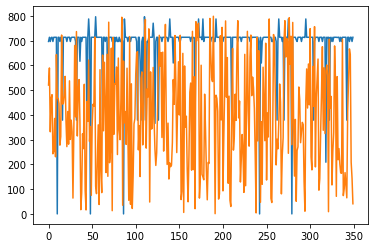

In [91]:
plt.plot(model_outs)
plt.plot([class_map[row['word']] for i, row in df.iterrows()])

In [88]:
[rev_map[i] for i in range(690, 704)]

['talking',
 'taught',
 'teams',
 'technology',
 'television',
 'terms',
 'thats',
 'their',
 'themselves',
 'theory',
 'there',
 'theres',
 'therefore',
 'these']

In [73]:
np.mean(results)

0.05142857142857143

In [49]:
ipd.Audio(cue.squeeze(0), rate=50000)

In [50]:
ipd.Audio(mixture.squeeze(0), rate=50000)

In [51]:
ipd.Audio(cue.squeeze(0), rate=50000)

In [80]:
rev_map = {v:k for k,v in class_map.items()}

In [81]:
rev_map[result]

'little'

In [76]:
## Make sure model can run on validation set 
config['num_workers'] = 5
config['hparas']['batch_size'] = 16
val_loader = model.val_dataloader()

49 files in val concat dataset


In [77]:
len(val_loader)

9355

In [79]:
model = model.eval()

results = []
n_to_measure = 10000 // 16
for i, batch in enumerate(tqdm.tqdm(val_loader ,total=n_to_measure)):
    if i == n_to_measure:
        break
    cue_features, cue_mask_ixs, scene_features, labels = batch
    out = model(cue_features.cuda(), scene_features.cuda(), None).softmax(-1).argmax(-1).cpu().numpy()
    results.extend(out == labels.numpy())

    
    

 27%|██▋       | 170/625 [03:55<10:30,  1.39s/it]


KeyboardInterrupt: 

In [81]:
np.mean(results)

0.0014705882352941176